# 01 · 特征探索:从波形到 log-mel

**目标**:肉眼确认整条特征管线是合理的——正例("yes")和负例的 log-mel 图应该长得明显不一样,增强后的特征应该"变了但没变形"。

**运行前提**:项目根目录下运行 Jupyter(`uv run jupyter lab`),Speech Commands v2 已在 `data/raw/speech_commands/`。

**阅读顺序**:本 notebook 按数据流走:原始波形 → log-mel → MFCC → 波形级增强 → 特征级增强(SpecAugment)→ Dataset 最终输出。正好对应你的学习顺序 `FeatureConfig → features.py → audio_io.py → augment.py → kws_datasets.py`。

In [22]:
# 环境与模块检查:先把每个模块暴露的函数打出来,
# 后面哪个 cell 的函数名对不上,回这里查真名改一下即可
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path

from my_kws import audio_io, features, augment
from my_kws.kws_datasets import KeywordSpottingDataset

for mod in (audio_io, features, augment):
    print(f"{mod.__name__}:", [n for n in dir(mod) if not n.startswith('_')])

DATA_ROOT = Path('data/raw/speech_commands')
if not DATA_ROOT.exists():
    import os
    os.chdir('..')                     # notebook 在 notebooks/ 下,退到项目根
    DATA_ROOT = Path('data/raw/speech_commands')
assert DATA_ROOT.exists(), '找不到数据目录'

my_kws.audio_io: ['AF', 'load_audio', 'np', 'rms', 'sf', 'snr_db', 'torch']
my_kws.features: ['F', 'T', 'frame', 'hz_to_mel', 'log_mel_spectrogram', 'mel_filterbank', 'mel_to_hz', 'mfcc', 'np', 'plt', 'scipy', 'stft', 'torch', 'window']
my_kws.augment: ['add_noise', 'np', 'random_time_shift', 'spec_augment']


## 1 · 原始波形

先各取一条正例和负例。Speech Commands 全部是 16 kHz、约 1 秒的单声道 wav。
注意看两点:振幅包络的形状("yes" 的 /j/-/ɛ/-/s/ 三段结构),以及录音长度是否恰好 16000 采样点(不足 1 秒的文件你的管线里应该有 padding 逻辑)。

sr=16000, pos shape=(16000,), neg shape=(16000,)


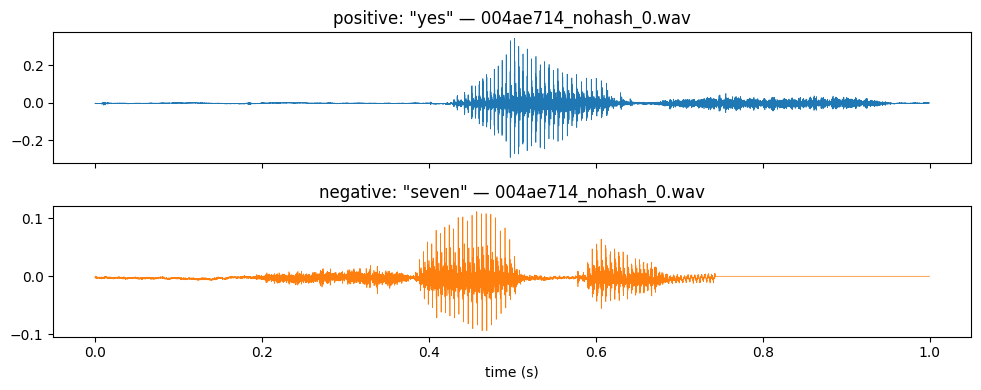

In [23]:
sr = 16000
pos_path = sorted((DATA_ROOT / 'yes').glob('*.wav'))[0]
neg_path = sorted((DATA_ROOT / 'seven').glob('*.wav'))[0]

wav_pos = audio_io.load_audio(pos_path, sr, True, 1.0)
wav_neg = audio_io.load_audio(neg_path, sr, True, 1.0)
print(f'sr={sr}, pos shape={wav_pos.shape}, neg shape={wav_neg.shape}')

fig, axes = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
t = np.arange(len(wav_pos)) / sr
axes[0].plot(t, wav_pos, lw=0.5); axes[0].set_title(f'positive: "yes" — {pos_path.name}')
axes[1].plot(np.arange(len(wav_neg)) / sr, wav_neg, lw=0.5, color='tab:orange')
axes[1].set_title(f'negative: "seven" — {neg_path.name}')
axes[1].set_xlabel('time (s)')
plt.tight_layout()

## 2 · log-mel 频谱图

这是模型真正"看到"的东西。检查点:
- 形状必须是 **(40, 98)**,即 (n_mels, n_frames),mel-major
- "yes" 应该能看到清晰的共振峰结构和结尾 /s/ 的高频能量
- 纵轴低索引 = 低频(mel filterbank 的排列方向)

shape: (40, 98)  (期望 (40, 98))


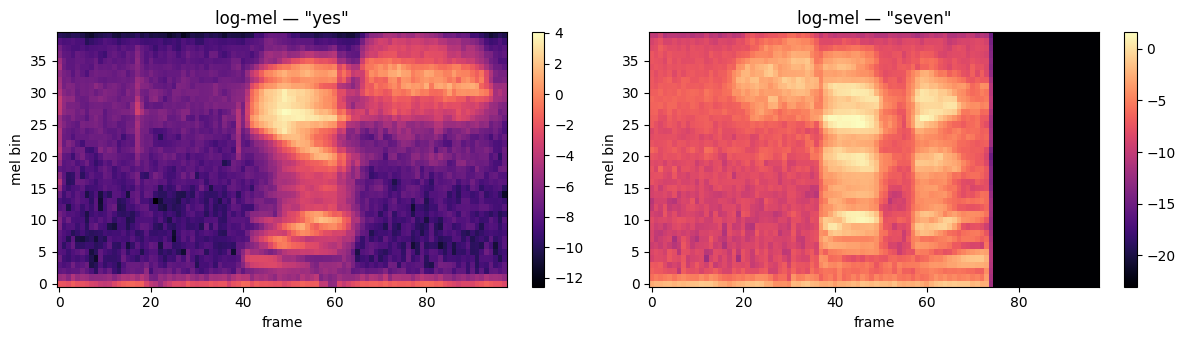

In [24]:
logmel_pos = features.log_mel_spectrogram(wav_pos)
logmel_neg = features.log_mel_spectrogram(wav_neg)
print('shape:', logmel_pos.shape, ' (期望 (40, 98))')

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for ax, m, title in [(axes[0], logmel_pos, '"yes"'), (axes[1], logmel_neg, '"seven"')]:
    im = ax.imshow(m, aspect='auto', origin='lower', cmap='magma')
    ax.set_title(f'log-mel — {title}')
    ax.set_xlabel('frame'); ax.set_ylabel('mel bin')
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()

## 3 · MFCC(对照参考)

我们训练用的是 log-mel(CNN 更喜欢保留局部结构的特征),但 MFCC 在传统 DSP/嵌入式 KWS 里非常常见,面试可能被问到两者取舍:
MFCC = log-mel 再做一次 DCT,去相关、更紧凑,但丢掉了 mel 轴上的局部性——这正是 CNN 卷积核想利用的东西。

MFCC shape: (13, 98)  (期望 (13, 98))


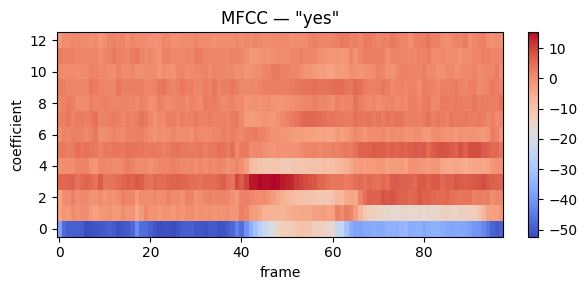

In [25]:
mfcc_pos = features.mfcc(logmel_pos)
print('MFCC shape:', mfcc_pos.shape, ' (期望 (13, 98))')

plt.figure(figsize=(6, 3))
plt.imshow(mfcc_pos, aspect='auto', origin='lower', cmap='coolwarm')
plt.title('MFCC — "yes"'); plt.xlabel('frame'); plt.ylabel('coefficient')
plt.colorbar(fraction=0.046)
plt.tight_layout()

## 4 · 波形级增强:time shift 与加噪

检查点:time shift 后频谱整体沿时间轴平移、内容不变;加噪后底噪抬升但语音结构仍清晰可辨(SNR 5–20 dB 的设计目标)。
下面 cell 的函数名同样以模块检查 cell 打印的为准。

noise source: doing_the_dishes.wav


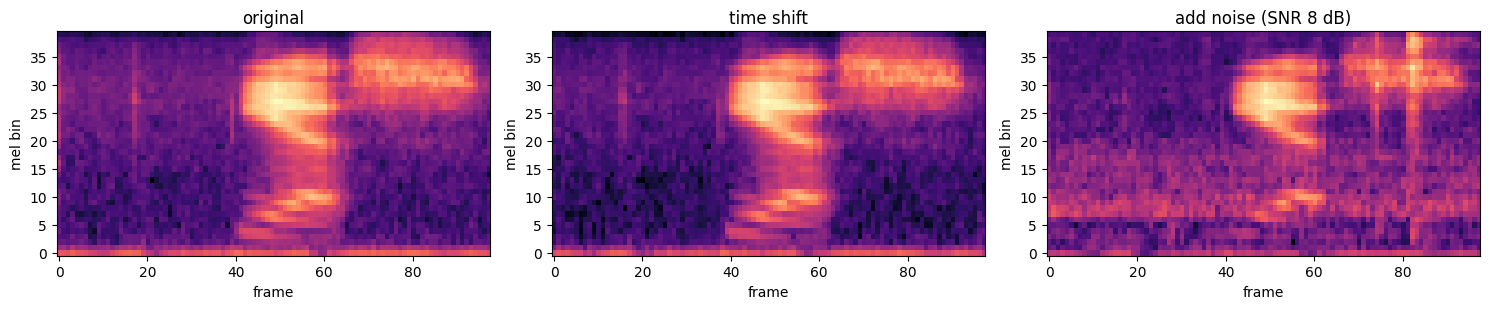

In [26]:
# 从 _background_noise_ 加载一段真实噪声
noise_path = sorted((DATA_ROOT / '_background_noise_').glob('*.wav'))[0]
noise, _ = __import__('soundfile').read(noise_path)
noise = noise.astype(np.float32)
print('noise source:', noise_path.name)

shifted = augment.random_time_shift(wav_pos, max_shift_samples=1600)
noisy   = augment.add_noise(wav_pos, noise, snr_db=8)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.2))
for ax, w, title in [(axes[0], wav_pos, 'original'),
                     (axes[1], shifted, 'time shift'),
                     (axes[2], noisy, 'add noise (SNR 8 dB)')]:
    m = features.log_mel_spectrogram(np.asarray(w))
    im = ax.imshow(m, aspect='auto', origin='lower', cmap='magma')
    ax.set_title(title); ax.set_xlabel('frame'); ax.set_ylabel('mel bin')
plt.tight_layout()

## 5 · 特征级增强:SpecAugment

检查点:遮蔽条带的方向必须正确——**时间遮蔽是竖条,频率遮蔽是横条**(你之前修过的 mask 轴 bug 就是这里,肉眼再确认一次)。

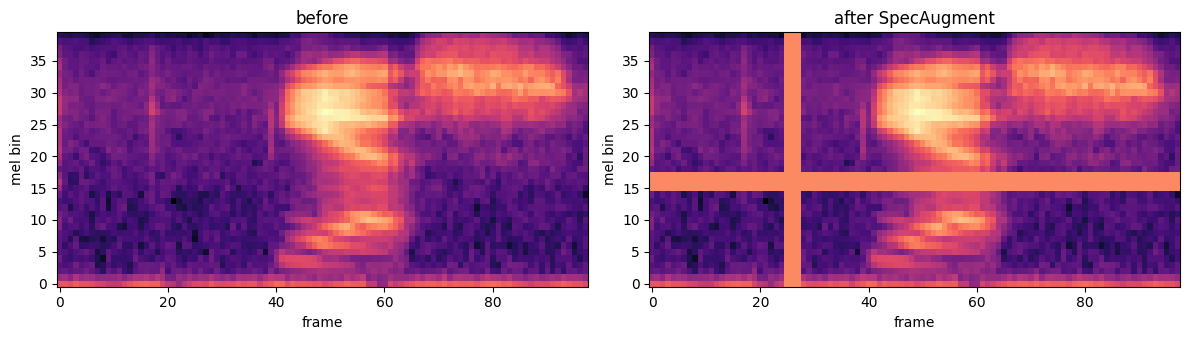

In [27]:
specaug = augment.spec_augment(logmel_pos)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for ax, m, title in [(axes[0], logmel_pos, 'before'), (axes[1], specaug, 'after SpecAugment')]:
    ax.imshow(m, aspect='auto', origin='lower', cmap='magma')
    ax.set_title(title); ax.set_xlabel('frame'); ax.set_ylabel('mel bin')
plt.tight_layout()

## 6 · Dataset 最终输出抽查

从 `KeywordSpottingDataset` 里随机抽 8 个训练样本,确认:形状 (1, 40, 98) float32、标签正确、增强开着的情况下特征看起来仍然合理。

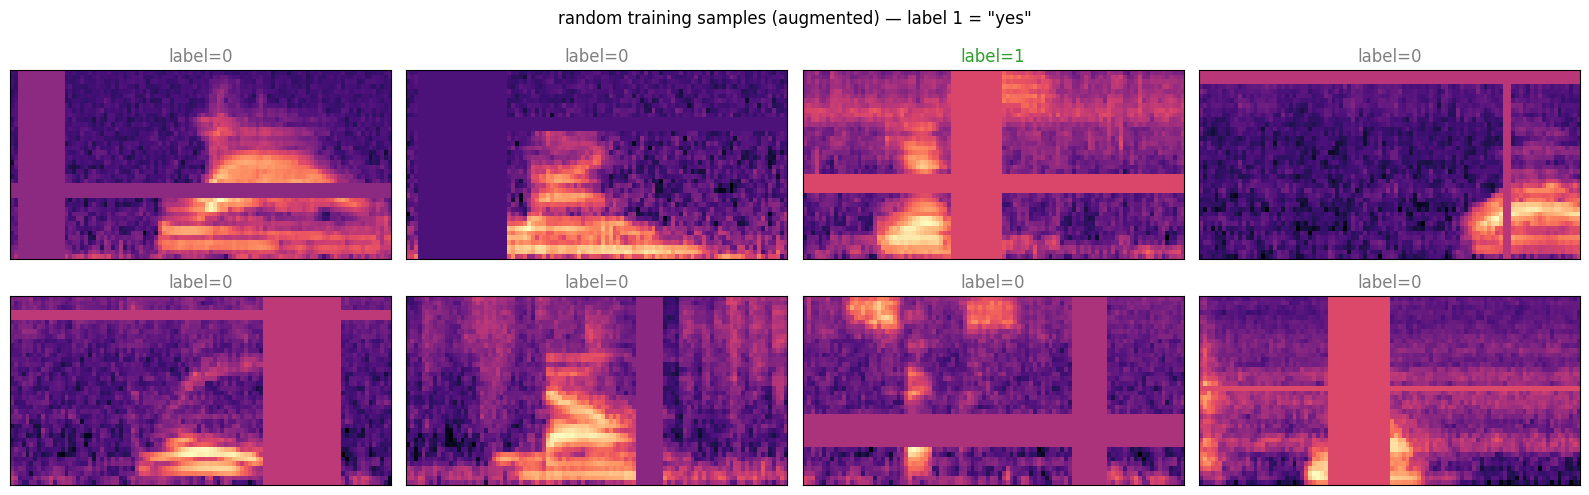

In [28]:
ds = KeywordSpottingDataset(root=DATA_ROOT, split='train', training=True, seed=0)
idx = np.random.default_rng(1).choice(len(ds), size=8, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(16, 5))
for ax, i in zip(axes.flat, idx):
    x, y = ds[int(i)]
    ax.imshow(x.squeeze(0).numpy(), aspect='auto', origin='lower', cmap='magma')
    ax.set_title(f'label={int(y)}', color='tab:green' if int(y) == 1 else 'tab:gray')
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('random training samples (augmented) — label 1 = "yes"')
plt.tight_layout()

## 7 · 训练曲线(训练启动后随时可跑)

直接读 `train.py` 写出的 `models/training_history.json`,训练进行中也能刷新看进度。

best so far: epoch 15, F1=0.930 (P=0.895, R=0.967)


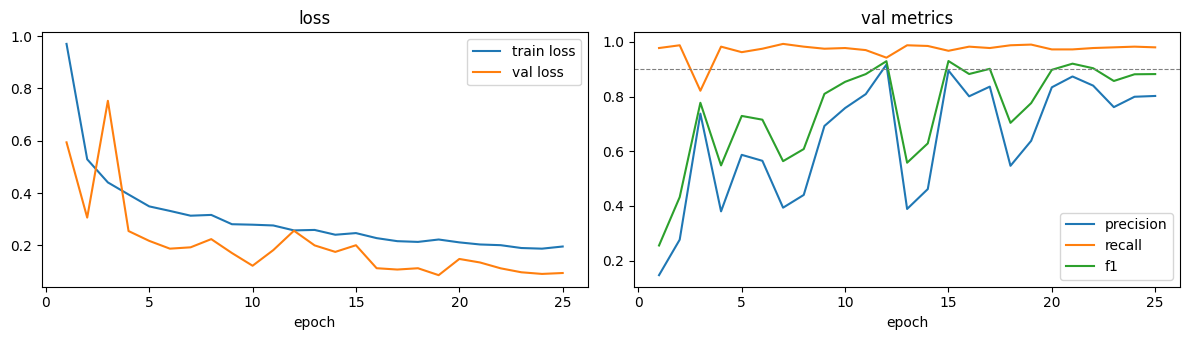

In [50]:
import json

hist_path = Path('models/training_history.json')
if hist_path.exists():
    hist = json.loads(hist_path.read_text())
    ep = [h['epoch'] for h in hist]
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
    axes[0].plot(ep, [h['train_loss'] for h in hist], label='train loss')
    axes[0].plot(ep, [h['loss'] for h in hist], label='val loss')
    axes[0].set_xlabel('epoch'); axes[0].legend(); axes[0].set_title('loss')
    for k in ('precision', 'recall', 'f1'):
        axes[1].plot(ep, [h[k] for h in hist], label=k)
    axes[1].set_xlabel('epoch'); axes[1].legend(); axes[1].set_title('val metrics')
    axes[1].axhline(0.9, ls='--', c='gray', lw=0.8)
    plt.tight_layout()
    best = max(hist, key=lambda h: h['f1'])
    print(f"best so far: epoch {best['epoch']}, F1={best['f1']:.3f} "
          f"(P={best['precision']:.3f}, R={best['recall']:.3f})")
else:
    print('models/training_history.json 还不存在——先启动训练')

---
**下一步(notebook 02 预告)**:baseline 训完后做特征缓存 vs 实时计算的对照实验——比较 epoch 耗时和最终 F1,量化"波形级增强换训练速度"这笔交易是否划算。